# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [2]:
# Sample study data
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'exam_score': [52, 55, 59, 63, 68, 72, 78, 85]
}

df = pd.DataFrame(data)

X = df[['hours_studied']]

y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')

print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.71
Intercept: 45.52


In [4]:
y_pred = model.predict(X_test)

print('Actual scores: ', list(y_test))

print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [55, 72]
Predicted scores: [np.float64(54.9), np.float64(73.8)]


In [5]:
r_squared = model.score(X_test, y_test)

print(f'R² score: {r_squared:.3f}')

R² score: 0.978


The R² score shows how much of the variation in exam scores is explained by hours studied.

A score closer to 1 means the model fits the data better.

C:\Users\smayamelgara\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


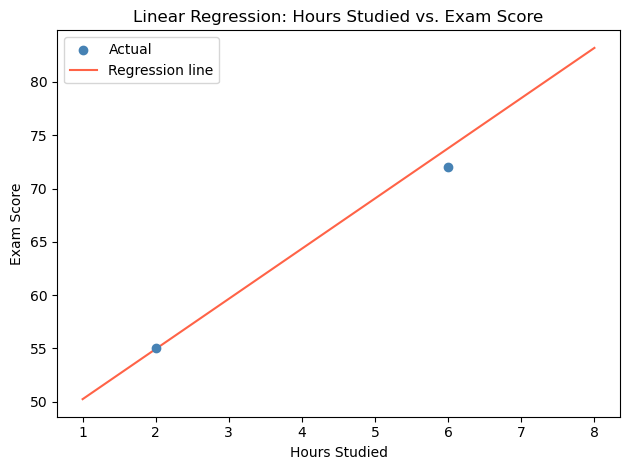

In [6]:
# Scatter plot: actual test data points
plt.scatter(
    X_test,
    y_test,
    color='steelblue',
    label='Actual',
    zorder=3
)

# Line: model predictions across the full range of X
x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_range)

plt.plot(
    x_range,
    y_line,
    color='tomato',
    label='Regression line'
)

plt.xlabel('Hours Studied')

plt.ylabel('Exam Score')

plt.title('Linear Regression: Hours Studied vs. Exam Score')

plt.legend()

plt.tight_layout()

plt.show()

The data points follow the regression line fairly closely.

This suggests there is a strong relationship between hours studied and exam scores.

## Lab 2
### Building your own model

In [8]:
ad_data = {
    'monthly_ad_spend': [
        500, 1000, 1500, 2000, 2500,
        3000, 3500, 4000, 4500, 5000,
        5500, 6000, 6500, 7000, 7500,
        8000, 8500, 9000, 9500, 10000
    ],

    'monthly_revenue': [
        4200, 5100, 6800, 7400, 8900,
        9200, 10500, 11800, 12400, 13100,
        14200, 15600, 15900, 17200, 18100,
        19400, 20200, 21500, 22100, 23800
    ]
}

df_ads = pd.DataFrame(ad_data)

df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [9]:
X2 = df_ads[['monthly_ad_spend']]

y2 = df_ads['monthly_revenue']

print(X2.shape)

print(y2.shape)

(20, 1)
(20,)


In [11]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [12]:
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

print("Model trained successfully.")

Model trained successfully.


In [13]:
print(f'Slope (coefficient): {model2.coef_[0]:.2f}')

print(f'Intercept: {model2.intercept_:.2f}')

# For each additional $1 spent on advertising,
# the predicted monthly revenue increases by the slope amount.

Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [15]:
y2_pred = model2.predict(X2_test)

print("Actual values:")

print(list(y2_test))

print("\nPredicted values:")

print(list(y2_pred.round(2)))


Actual values:
[4200, 21500, 19400, 5100]

Predicted values:
[np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [16]:
r2_score = model2.score(X2_test, y2_test)

print(f'R² score: {r2_score:.3f}')

R² score: 0.998


The model appears to fit the data well if the R² score is close to 1.

The R² score represents the percentage of variation in revenue explained by ad spend.

### Visualizing the results

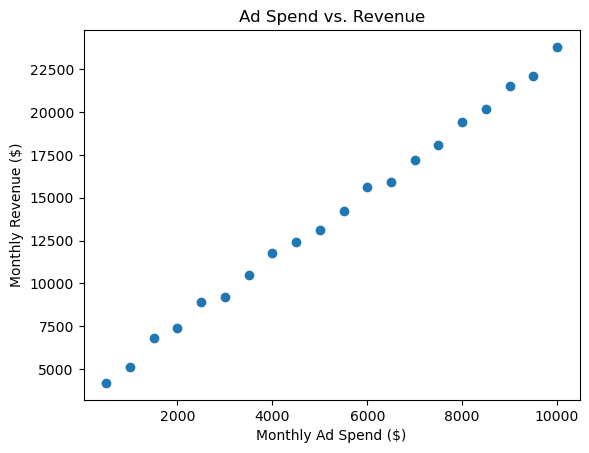

In [17]:
plt.scatter(X2, y2)

plt.xlabel('Monthly Ad Spend ($)')

plt.ylabel('Monthly Revenue ($)')

plt.title('Ad Spend vs. Revenue')

plt.show()

C:\Users\smayamelgara\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


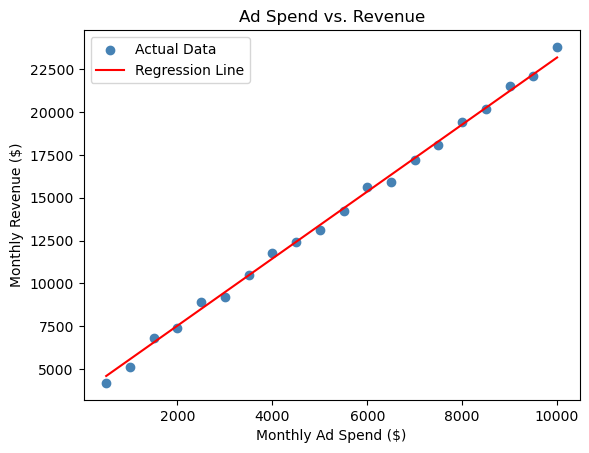

In [18]:
plt.scatter(
    X2,
    y2,
    color='steelblue',
    label='Actual Data'
)

x2_range = np.linspace(
    X2['monthly_ad_spend'].min(),
    X2['monthly_ad_spend'].max(),
    100
).reshape(-1, 1)

y2_line = model2.predict(x2_range)

plt.plot(
    x2_range,
    y2_line,
    color='red',
    label='Regression Line'
)

plt.xlabel('Monthly Ad Spend ($)')

plt.ylabel('Monthly Revenue ($)')

plt.title('Ad Spend vs. Revenue')

plt.legend()

plt.show()

The regression line appears to fit the data well visually because the points stay close to the line.

This matches the R² score because a higher R² usually means a better fitting regression line.